In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def show_images_side_by_side(title1, image1, title2, image2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    if image1 is not None:
        ax1.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
    ax1.set_title(title1)
    ax1.axis('off')
    
    if image2 is not None:
        ax2.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
    ax2.set_title(title2)
    ax2.axis('off')
    
    plt.show()

--- Imágenes Segmentadas Originales Cargadas ---


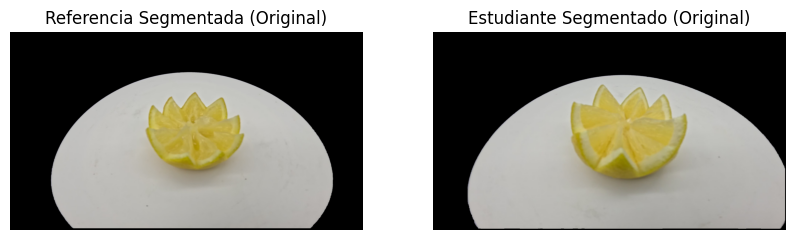

In [2]:
REF_SEGMENTED_PATH = '/home/jaqueline/Documentos/proyecto-integrador/imagenes_segmentadas/limon-bueno_cleaned_morph.png'
STUDENT_SEGMENTED_PATH = '/home/jaqueline/Documentos/proyecto-integrador/imagenes_segmentadas/limon-chef_cleaned_morph.png'

ref_image = cv2.imread(REF_SEGMENTED_PATH)
student_image = cv2.imread(STUDENT_SEGMENTED_PATH)

if ref_image is not None and student_image is not None:
    print("--- Imágenes Segmentadas Originales Cargadas ---")
    show_images_side_by_side('Referencia Segmentada (Original)', ref_image, 'Estudiante Segmentado (Original)', student_image)
else:
    print("Error: No se pudieron cargar las imágenes. Verifica las rutas.")


--- Procesando: Alineación + Filtro de Mediana ---
  -> Filtro de Mediana (5x5) aplicado

Imagen Chef Guardada: imagenes_alineadas_Final_Filtradas/limon-bueno_cleaned_morph_final.png
Imagen Estudiante Guardada: imagenes_alineadas_Final_Filtradas/limon-chef_cleaned_morph_final.png


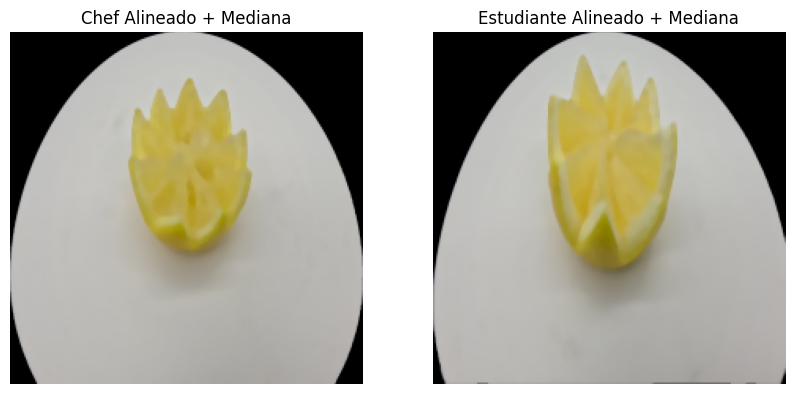

In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np
import cv2
import os

def crear_vistas_consistentes(ref_image, student_image, final_size=(224, 224)):
    """
    Toma la imagen de referencia y del estudiante, las alinea, las escala
    y les aplica un filtro de Mediana para reducción de ruido.
    """

    def procesar_imagen_base(image):
        if image is None or image.size == 0:
            return None
            
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None

        main_contour = max(contours, key=cv2.contourArea)
        center, (width, height), angle = cv2.minAreaRect(main_contour)
        if width < height:
            angle += 90

        h, w = image.shape[:2]
        rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
     
        cos = np.abs(rotation_matrix[0, 0])
        sin = np.abs(rotation_matrix[0, 1])
        new_w = int((h * sin) + (w * cos))
        new_h = int((h * cos) + (w * sin))
        
        rotation_matrix[0, 2] += (new_w / 2) - center[0]
        rotation_matrix[1, 2] += (new_h / 2) - center[1]
        
        rotated = cv2.warpAffine(image, rotation_matrix, (new_w, new_h), 
                                 flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0))

        gray_rotated = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)
        _, thresh_rotated = cv2.threshold(gray_rotated, 1, 255, cv2.THRESH_BINARY)
        contours_rotated, _ = cv2.findContours(thresh_rotated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours_rotated:
            return cv2.resize(rotated, final_size)

        x, y, w_box, h_box = cv2.boundingRect(max(contours_rotated, key=cv2.contourArea))
        cropped = rotated[y:y+h_box, x:x+w_box]
        return cropped

    # Procesamiento base (Alineación y Recorte)
    ref_base = procesar_imagen_base(ref_image)
    student_base = procesar_imagen_base(student_image)

    if ref_base is None or student_base is None:
        print("Error en el procesamiento base de una de las imágenes.")
        return None, None
        
    # Redimensionarmiento 
    final_ref = cv2.resize(ref_base, final_size, interpolation=cv2.INTER_AREA)
    student_cand_1 = cv2.resize(student_base, final_size, interpolation=cv2.INTER_AREA)
    
    # Comparación de 180 grados
    student_cand_2 = cv2.rotate(student_cand_1, cv2.ROTATE_180)
    gray_ref = cv2.cvtColor(final_ref, cv2.COLOR_BGR2GRAY)
    gray_stu_1 = cv2.cvtColor(student_cand_1, cv2.COLOR_BGR2GRAY)
    gray_stu_2 = cv2.cvtColor(student_cand_2, cv2.COLOR_BGR2GRAY)

    score_1, _ = ssim(gray_ref, gray_stu_1, full=True)
    score_2, _ = ssim(gray_ref, gray_stu_2, full=True)

    if score_2 > score_1:
        final_student = student_cand_2
    else:
        final_student = student_cand_1

# Aplicación de Filtro de Mediana para reducción de ruido
    final_ref = cv2.medianBlur(final_ref, 5)
    final_student = cv2.medianBlur(final_student, 5)
    print(" Filtro de Mediana (5x5) aplicado")

    return final_ref, final_student

if 'ref_image' in locals() and 'student_image' in locals():
    OUTPUT_FOLDER = 'imagenes_alineadas_Final_Filtradas/' 
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    print("\n--- Procesando: Alineación + Filtro de Mediana ---")
    ref_final, student_final = crear_vistas_consistentes(ref_image, student_image)
    
    if ref_final is not None and student_final is not None:
        ref_basename = os.path.basename(REF_SEGMENTED_PATH)
        student_basename = os.path.basename(STUDENT_SEGMENTED_PATH)
        output_path_ref = os.path.join(OUTPUT_FOLDER, ref_basename.replace('.png', '_final.png'))
        output_path_student = os.path.join(OUTPUT_FOLDER, student_basename.replace('.png', '_final.png'))
        
        cv2.imwrite(output_path_ref, ref_final)
        cv2.imwrite(output_path_student, student_final)
        
        print(f"\nImagen Chef Guardada: {output_path_ref}")
        print(f"Imagen Estudiante Guardada: {output_path_student}")
        
        show_images_side_by_side('Chef Alineado + Mediana', ref_final, 'Estudiante Alineado + Mediana', student_final)